red square  image=(32, 32, 3) label=0 box=[5, 7, 16, 18] mask=(32, 32) object_pixels=121
blue circle image=(32, 32, 3) label=1 box=[17, 13, 28, 24] mask=(32, 32) object_pixels=81
original true=red square  predicted=red square  mask_IoU=1.00
darkened true=red square  predicted=blue circle mask_IoU=0.00


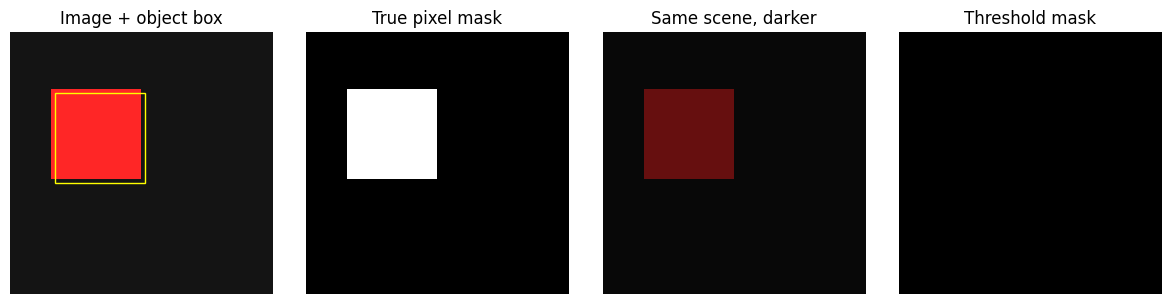

In [ ]:
### CS231n_Lec01_review_CV_Tasks including Image classification, object localization, pixel segmentation


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

## set values to create shape samples
H = W = 32
NAMES = ("red square", "blue circle")


## define the function to make arbitrary sample(red square OR blue circle)
def make_scene(kind, cx, cy, radius=5):
    # Create images, classification labels, object boxes, and pixel masks.
    image = np.full((H, W, 3), 0.08, dtype=np.float32)

     # np.mgrid → Create array of row and column coordinates for all pixels
    yy, xx = np.mgrid[:H, :W]

    if kind == "square":
    # mask → A Boolean mask array defining a shape region using a mathematical expression.
        mask = (abs(xx - cx) <= radius) & (abs(yy - cy) <= radius)

        # (1.0, 0.15, 0.15) → red color
        color, label = (1.0, 0.15, 0.15), 0
    else: # kind == "circle"
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2

        # (0.15, 0.25, 1.0) → blue color
        color, label = (0.15, 0.25, 1.0), 1

    # Coloring the shape area by applying a mask array
    image[mask] = color

    # Box the shape area based on the maximum and minimum coordinate values
    ys, xs = np.where(mask)
    box = np.array([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1])
    return image, label, box, mask


## define the function
def fixed_threshold(image):

    # Set simple decision rules vulnerable to brightness changes.
    red = image[..., 0] > 0.5 # Red axis = 0(RGB)
    blue = image[..., 2] > 0.5 # Blue axis = 2(RGB)

    # Compare the number of pixels by color standards
    predicted_class = 0 if red.sum() > blue.sum() else 1

    # create mask area where pixel value is over 0.5
    predicted_mask = red | blue

    return predicted_class, predicted_mask


## define the function to calculate the intersection-to-union ratio
def iou(a, b):
    # intersection: the number of pixels in which both images are True
    # union: the number of pixels in which either image is
    intersection = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return intersection / union if union else 1.0


## create the arbitrary shape sample by designed functions
square = make_scene("square", cx=10, cy=12)
circle = make_scene("circle", cx=22, cy=18)


## Check the values of image datas and make the dark image(just change the brightness, keeping other factors)
for image, label, box, mask in (square, circle):

    # check the value information
    print(
        f"{NAMES[label]:11s} image={image.shape} "
        f"label={label} box={box.tolist()} mask={mask.shape} "
        f"object_pixels={mask.sum()}"
    )

# remind: square's shape  → image, label, box, mask
image, label, box, mask = square

# dark_image → Just the brightness is altered with objects and positions unchanged.
dark_image = image * 0.4


## Predict pixel labels & shape areas and Compare the target and predicted reulsts
for name, sample in (("original", image), ("darkened", dark_image)):
    predicted_class, predicted_mask = fixed_threshold(sample)
    print(
        f"{name:8s} true={NAMES[label]:11s} "
        f"predicted={NAMES[predicted_class]:11s} "
        f"mask_IoU={iou(mask, predicted_mask):.2f}"
    )

# visualizing the shape target and predicted areas
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image)
axes[0].add_patch(
    Rectangle(
        (box[0], box[1]),
        box[2] - box[0],
        box[3] - box[1],
        fill=False,
        edgecolor="yellow",
    )
)
axes[0].set_title("Image + object box")
axes[1].imshow(mask, vmin=0, vmax=1, cmap="gray")
axes[1].set_title("True pixel mask")
axes[2].imshow(dark_image)
axes[2].set_title("Same scene, darker")
axes[3].imshow(
    fixed_threshold(dark_image)[1], vmin=0, vmax=1, cmap="gray"
)
axes[3].set_title("Threshold mask")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()